In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
import time
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
PROC_DIR = "."
test_df_standard = pd.read_csv("../Datasets/test.csv")
test_df_interp = pd.read_csv("../Datasets/test_interpolated.csv")

import json
from sklearn.preprocessing import LabelEncoder
with open("../api/labels.json", "r", encoding="utf-8") as f:
    labels_dict = json.load(f)
classes = [labels_dict[str(i)]["id"] for i in range(len(labels_dict))]
le = LabelEncoder()
le.fit(classes)

test_df_standard['label'] = le.transform(test_df_standard['label'])
test_df_interp['label'] = le.transform(test_df_interp['label'])

class SignDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(f"{PROC_DIR}/{row.file}").astype(np.float32)
        y = int(row.label)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)

test_loader_standard = DataLoader(SignDataset(test_df_standard), batch_size=32, shuffle=False)
test_loader_interp = DataLoader(SignDataset(test_df_interp), batch_size=32, shuffle=False)

single_loader_standard = DataLoader(SignDataset(test_df_standard), batch_size=1, shuffle=False)
single_loader_interp = DataLoader(SignDataset(test_df_interp), batch_size=1, shuffle=False)

input_dim = 387
num_classes = len(classes)


In [3]:
class TransformerSignModel(nn.Module):
    def __init__(self, input_dim=387, num_classes=401, d_model=256, nhead=8, num_layers=3, dropout=0.3):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU()
        )
        self.pos_encoder = nn.Parameter(torch.randn(1, 60, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        B, T, F = x.shape
        x = self.input_projection(x)
        x = x + self.pos_encoder[:, :T, :]
        x = self.transformer_encoder(x)
        x = torch.mean(x, dim=1)
        return self.fc(x)

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=387, num_classes=401, conv_filters=128, lstm_hidden=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=input_dim, out_channels=conv_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=conv_filters, out_channels=conv_filters, kernel_size=3, padding=1),
            nn.BatchNorm1d(conv_filters),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.lstm = nn.LSTM(
            input_size=conv_filters,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
        
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = x.transpose(1, 2)
        lstm_out, _ = self.lstm(x)
        attn_weights = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(lstm_out * attn_weights, dim=1)
        out = self.fc(context)
        return out


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

trans_std = TransformerSignModel(input_dim, num_classes).to(device)
trans_std.load_state_dict(torch.load("../Models/transformer_frontveiw.pth", map_location=device))
trans_std.eval()

trans_int = TransformerSignModel(input_dim, num_classes).to(device)
trans_int.load_state_dict(torch.load("../Models/transformer_interpolated_frontveiw.pth", map_location=device))
trans_int.eval()

cnn_std = CNNBiLSTMAttention(input_dim, num_classes).to(device)
cnn_std.load_state_dict(torch.load("../Models/cnn_bilstm_attention_frontveiw.pth", map_location=device))
cnn_std.eval()

cnn_int = CNNBiLSTMAttention(input_dim, num_classes).to(device)
cnn_int.load_state_dict(torch.load("../Models/cnn_bilstm_attention_interpolated_frontveiw.pth", map_location=device))
cnn_int.eval()

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Transformer (Standard) parameter count: {count_params(trans_std):,}")
print(f"Transformer (Interpolated) parameter count: {count_params(trans_int):,}")
print(f"CNN-BiLSTM (Standard) parameter count: {count_params(cnn_std):,}")
print(f"CNN-BiLSTM (Interpolated) parameter count: {count_params(cnn_int):,}")


Using device: cuda
Transformer (Standard) parameter count: 2,587,537
Transformer (Interpolated) parameter count: 2,587,537
CNN-BiLSTM (Standard) parameter count: 977,554
CNN-BiLSTM (Interpolated) parameter count: 977,554


In [5]:
# Evaluate Accuracy & WER on test set
def evaluate_accuracy(model, loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            preds = model(X)
            all_preds.extend(preds.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    wer = 1.0 - acc
    return acc, wer

trans_std_acc, trans_std_wer = evaluate_accuracy(trans_std, test_loader_standard)
trans_int_acc, trans_int_wer = evaluate_accuracy(trans_int, test_loader_interp)
cnn_std_acc, cnn_std_wer = evaluate_accuracy(cnn_std, test_loader_standard)
cnn_int_acc, cnn_int_wer = evaluate_accuracy(cnn_int, test_loader_interp)

print(f"Transformer (Standard) Accuracy: {trans_std_acc * 100:.2f}% | WER: {trans_std_wer * 100:.2f}%")
print(f"Transformer (Interpolated) Accuracy: {trans_int_acc * 100:.2f}% | WER: {trans_int_wer * 100:.2f}%")
print(f"CNN-BiLSTM (Standard) Accuracy: {cnn_std_acc * 100:.2f}% | WER: {cnn_std_wer * 100:.2f}%")
print(f"CNN-BiLSTM (Interpolated) Accuracy: {cnn_int_acc * 100:.2f}% | WER: {cnn_int_wer * 100:.2f}%")


Transformer (Standard) Accuracy: 90.08% | WER: 9.92%
Transformer (Interpolated) Accuracy: 93.39% | WER: 6.61%
CNN-BiLSTM (Standard) Accuracy: 92.64% | WER: 7.36%
CNN-BiLSTM (Interpolated) Accuracy: 94.40% | WER: 5.60%


In [6]:
# Inference Latency benchmarking
def measure_latency(model, loader, runs=100, use_device=device):
    model.to(use_device)
    # Warm up
    with torch.no_grad():
        for idx, (X, _) in enumerate(loader):
            if idx > 10:
                break
            _ = model(X.to(use_device))
            
    # Time iterations
    start_time = time.perf_counter()
    with torch.no_grad():
        count = 0
        for X, _ in loader:
            _ = model(X.to(use_device))
            count += 1
            if count >= runs:
                break
    total_time = time.perf_counter() - start_time
    return (total_time / count) * 1000 # in milliseconds

# Latency on GPU
trans_std_lat_gpu = measure_latency(trans_std, single_loader_standard, runs=200, use_device=device)
trans_int_lat_gpu = measure_latency(trans_int, single_loader_interp, runs=200, use_device=device)
cnn_std_lat_gpu = measure_latency(cnn_std, single_loader_standard, runs=200, use_device=device)
cnn_int_lat_gpu = measure_latency(cnn_int, single_loader_interp, runs=200, use_device=device)

# Latency on CPU
trans_std_lat_cpu = measure_latency(trans_std, single_loader_standard, runs=200, use_device="cpu")
trans_int_lat_cpu = measure_latency(trans_int, single_loader_interp, runs=200, use_device="cpu")
cnn_std_lat_cpu = measure_latency(cnn_std, single_loader_standard, runs=200, use_device="cpu")
cnn_int_lat_cpu = measure_latency(cnn_int, single_loader_interp, runs=200, use_device="cpu")

print(f"GPU Latencies - Trans Std: {trans_std_lat_gpu:.2f} ms | Trans Int: {trans_int_lat_gpu:.2f} ms | CNN Std: {cnn_std_lat_gpu:.2f} ms | CNN Int: {cnn_int_lat_gpu:.2f} ms")
print(f"CPU Latencies - Trans Std: {trans_std_lat_cpu:.2f} ms | Trans Int: {trans_int_lat_cpu:.2f} ms | CNN Std: {cnn_std_lat_cpu:.2f} ms | CNN Int: {cnn_int_lat_cpu:.2f} ms")


GPU Latencies - Trans Std: 2.84 ms | Trans Int: 2.85 ms | CNN Std: 3.23 ms | CNN Int: 3.21 ms
CPU Latencies - Trans Std: 2.48 ms | Trans Int: 2.55 ms | CNN Std: 3.30 ms | CNN Int: 3.26 ms


In [7]:
# Model sizes on disk
trans_std_size = os.path.getsize("../Models/transformer_frontveiw.pth") / (1024 * 1024)
trans_int_size = os.path.getsize("../Models/transformer_interpolated_frontveiw.pth") / (1024 * 1024)
cnn_std_size = os.path.getsize("../Models/cnn_bilstm_attention_frontveiw.pth") / (1024 * 1024)
cnn_int_size = os.path.getsize("../Models/cnn_bilstm_attention_interpolated_frontveiw.pth") / (1024 * 1024)

print(f"Weights sizes - Trans Std: {trans_std_size:.2f} MB | Trans Int: {trans_int_size:.2f} MB | CNN Std: {cnn_std_size:.2f} MB | CNN Int: {cnn_int_size:.2f} MB")


Weights sizes - Trans Std: 9.89 MB | Trans Int: 9.89 MB | CNN Std: 3.74 MB | CNN Int: 3.74 MB


In [8]:
# Compile Benchmark Table
metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy (%)",
        "Word Error Rate (WER %)",
        "Parameters count",
        "Checkpoint size (MB)",
        "Latency CPU (ms)",
        "Latency GPU (ms)"
    ],
    "Transformer (Standard)": [
        trans_std_acc * 100,
        trans_std_wer * 100,
        count_params(trans_std),
        trans_std_size,
        trans_std_lat_cpu,
        trans_std_lat_gpu
    ],
    "Transformer (Interpolated)": [
        trans_int_acc * 100,
        trans_int_wer * 100,
        count_params(trans_int),
        trans_int_size,
        trans_int_lat_cpu,
        trans_int_lat_gpu
    ],
    "CNN-BiLSTM (Standard)": [
        cnn_std_acc * 100,
        cnn_std_wer * 100,
        count_params(cnn_std),
        cnn_std_size,
        cnn_std_lat_cpu,
        cnn_std_lat_gpu
    ],
    "CNN-BiLSTM (Interpolated)": [
        cnn_int_acc * 100,
        cnn_int_wer * 100,
        count_params(cnn_int),
        cnn_int_size,
        cnn_int_lat_cpu,
        cnn_int_lat_gpu
    ]
})

metrics_df = metrics_df.round(2)
metrics_df


,Metric,Transformer (Standard),Transformer (Interpolated),CNN-BiLSTM (Standard),CNN-BiLSTM (Interpolated)
0,Accuracy (%),90.08,93.39,92.64,94.40
1,Word Error Rate (WER %),9.92,6.61,7.36,5.60
2,Parameters count,2587537.00,2587537.00,977554.00,977554.00
3,Checkpoint size (MB),9.89,9.89,3.74,3.74
4,Latency CPU (ms),2.48,2.55,3.30,3.26
5,Latency GPU (ms),2.84,2.85,3.23,3.21


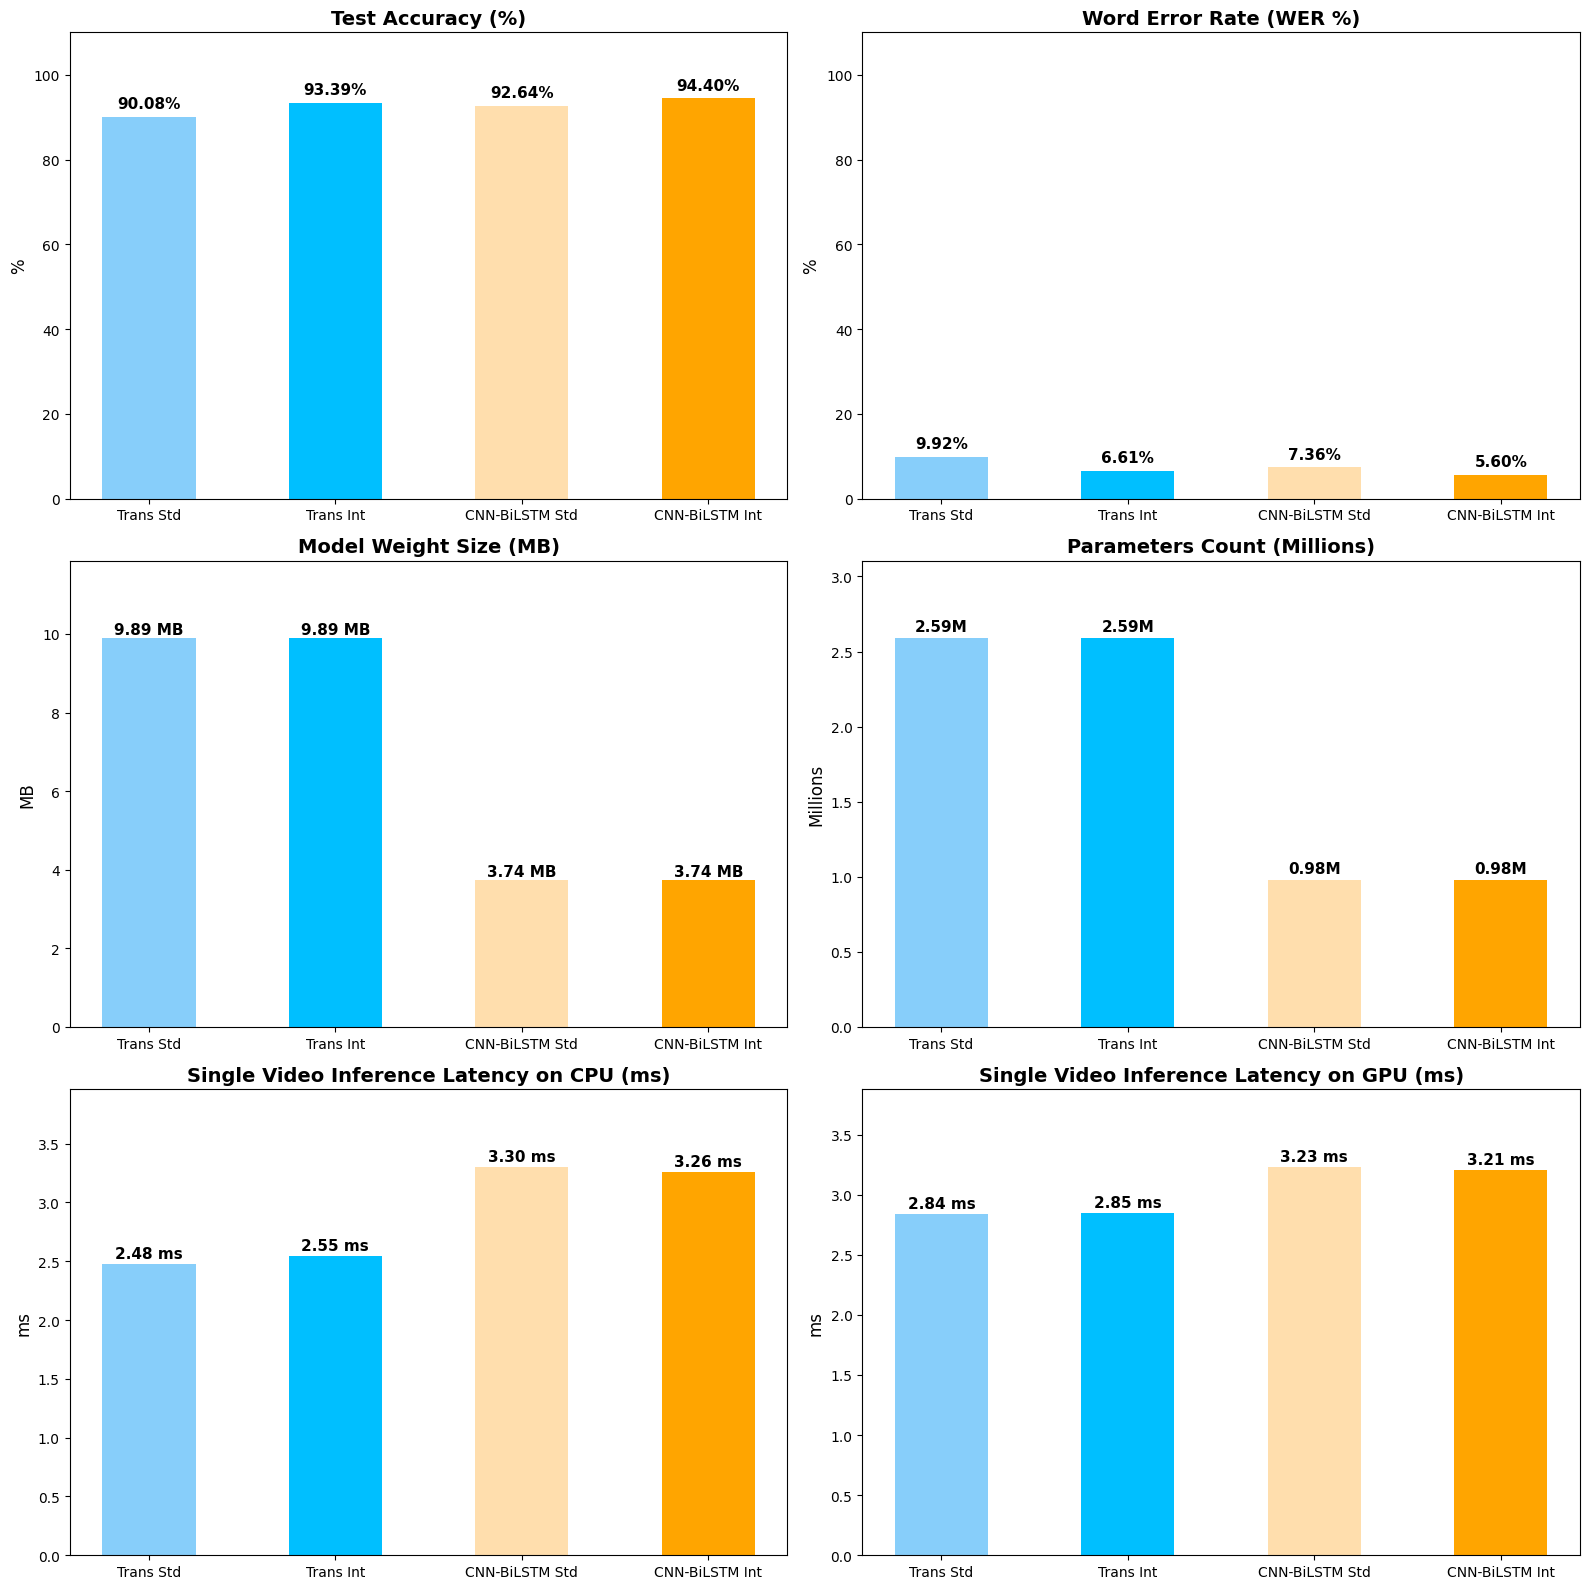

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

models = ["Trans Std", "Trans Int", "CNN-BiLSTM Std", "CNN-BiLSTM Int"]
colors = ["lightskyblue", "deepskyblue", "navajowhite", "orange"]

# Plot 1: Accuracy comparison
axes[0, 0].bar(models, [trans_std_acc * 100, trans_int_acc * 100, cnn_std_acc * 100, cnn_int_acc * 100], color=colors, width=0.5)
axes[0, 0].set_title("Test Accuracy (%)", fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel("%", fontsize=12)
axes[0, 0].set_ylim(0, 110)
for i, v in enumerate([trans_std_acc * 100, trans_int_acc * 100, cnn_std_acc * 100, cnn_int_acc * 100]):
    axes[0, 0].text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)

# Plot 2: Word Error Rate (WER) comparison
axes[0, 1].bar(models, [trans_std_wer * 100, trans_int_wer * 100, cnn_std_wer * 100, cnn_int_wer * 100], color=colors, width=0.5)
axes[0, 1].set_title("Word Error Rate (WER %)", fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel("%", fontsize=12)
axes[0, 1].set_ylim(0, 110)
for i, v in enumerate([trans_std_wer * 100, trans_int_wer * 100, cnn_std_wer * 100, cnn_int_wer * 100]):
    axes[0, 1].text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)

# Plot 3: Checkpoint size comparison
axes[1, 0].bar(models, [trans_std_size, trans_int_size, cnn_std_size, cnn_int_size], color=colors, width=0.5)
axes[1, 0].set_title("Model Weight Size (MB)", fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel("MB", fontsize=12)
axes[1, 0].set_ylim(0, max([trans_std_size, trans_int_size, cnn_std_size, cnn_int_size]) * 1.2)
for i, v in enumerate([trans_std_size, trans_int_size, cnn_std_size, cnn_int_size]):
    axes[1, 0].text(i, v + 0.1, f"{v:.2f} MB", ha='center', fontweight='bold', fontsize=11)

# Plot 4: Param count comparison
trans_std_m = count_params(trans_std)/1e6
trans_int_m = count_params(trans_int)/1e6
cnn_std_m = count_params(cnn_std)/1e6
cnn_int_m = count_params(cnn_int)/1e6
axes[1, 1].bar(models, [trans_std_m, trans_int_m, cnn_std_m, cnn_int_m], color=colors, width=0.5)
axes[1, 1].set_title("Parameters Count (Millions)", fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel("Millions", fontsize=12)
axes[1, 1].set_ylim(0, max([trans_std_m, trans_int_m, cnn_std_m, cnn_int_m]) * 1.2)
for i, v in enumerate([trans_std_m, trans_int_m, cnn_std_m, cnn_int_m]):
    axes[1, 1].text(i, v + 0.05, f"{v:.2f}M", ha='center', fontweight='bold', fontsize=11)

# Plot 5: Latency CPU comparison
axes[2, 0].bar(models, [trans_std_lat_cpu, trans_int_lat_cpu, cnn_std_lat_cpu, cnn_int_lat_cpu], color=colors, width=0.5)
axes[2, 0].set_title("Single Video Inference Latency on CPU (ms)", fontsize=14, fontweight='bold')
axes[2, 0].set_ylabel("ms", fontsize=12)
axes[2, 0].set_ylim(0, max([trans_std_lat_cpu, trans_int_lat_cpu, cnn_std_lat_cpu, cnn_int_lat_cpu]) * 1.2)
for i, v in enumerate([trans_std_lat_cpu, trans_int_lat_cpu, cnn_std_lat_cpu, cnn_int_lat_cpu]):
    axes[2, 0].text(i, v + 0.05, f"{v:.2f} ms", ha='center', fontweight='bold', fontsize=11)

# Plot 6: Latency GPU comparison
axes[2, 1].bar(models, [trans_std_lat_gpu, trans_int_lat_gpu, cnn_std_lat_gpu, cnn_int_lat_gpu], color=colors, width=0.5)
axes[2, 1].set_title("Single Video Inference Latency on GPU (ms)", fontsize=14, fontweight='bold')
axes[2, 1].set_ylabel("ms", fontsize=12)
axes[2, 1].set_ylim(0, max([trans_std_lat_gpu, trans_int_lat_gpu, cnn_std_lat_gpu, cnn_int_lat_gpu]) * 1.2)
for i, v in enumerate([trans_std_lat_gpu, trans_int_lat_gpu, cnn_std_lat_gpu, cnn_int_lat_gpu]):
    axes[2, 1].text(i, v + 0.05, f"{v:.2f} ms", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()
